## Define the Environment
We first define the environment including the number of states, actions, goal state and the Q-table.
Each state represents a position in a 4×4 grid and actions represent movements in four directions.

#### State:
Represents the current situation of the agent in the environment — everything the agent needs to know to decide its next action.

###### [taxi_row, taxi_col, passenger_location, destination]

#### The goal state (also called terminal state or goal condition):
Is a specific state that satisfies the objective of the problem — where the episode should end.

   * The goal state is when:

     * The passenger has been successfully picked up,

     * And dropped off at the correct destination.

### Libraries

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
state_n = 16
action_n = 4
goal_state = 15 # This means state number 15 is the goal state

##### State:
 * When we have 16 states, it’s often a 4×4 grid world.
 * Example grid (state numbering from 0 to 15):
     * 0   1   2   3
     * 4   5   6   7
     * 8   9  10  11
     * 12 13  14  15
##### Goal State:
 * Is the number = 15 in the state above.

In [30]:
# Q_table 
q_table = np.zeros((state_n, action_n))
# q_table

In [31]:
ALPHA = 0.8
GAMMA = 0.95
epsilon = 0.2
epochs = 1000

#### Define the State Transition Function.
This function calculates the next state based on the current state and chosen action.

We assume:
* 0 → Left
* 1 → Right
* 2 → Up
* 3 → Down

In [32]:
def get_next_state(state, action):
    row, col = divmod(state, 4) # divmod(a, b) == (a // b, a % b). our state 4x4 gride will be in row(0 1 2 3) and col(0 1 2 3)

    if action == 0 and col > 0:      # Left
        col -= 1
    elif action == 1 and col < 3:    # Right
        col += 1
    elif action == 2 and row > 0:    # Up
        row -= 1
    elif action == 3 and row < 3:    # Down
        row += 1

    return row * 4 + col


In [57]:
get_next_state(7, 0)

6

### Implement the Q-Learning Algorithm:
* Now we train the agent to learn the optimal policy. At each step:

*Choose an action using epsilon-greedy policy.
  * Move to the next state based on that action.
  * Update the Q-value using the Bellman equation.
  * End the episode if the goal is reached.

In [34]:
for epesod in range(epochs):
    current_state = np.random.randint(0, state_n)

    while True:
        if np.random.rand() < epsilon:
            action = np.random.randint(0, action_n)
        else:
            action = np.argmax(q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        q_table[current_state, action] += ALPHA  * (reward + GAMMA * np.max(q_table[next_state]) - q_table[current_state, action])

        if next_state == goal_state:
            break

        current_state = next_state

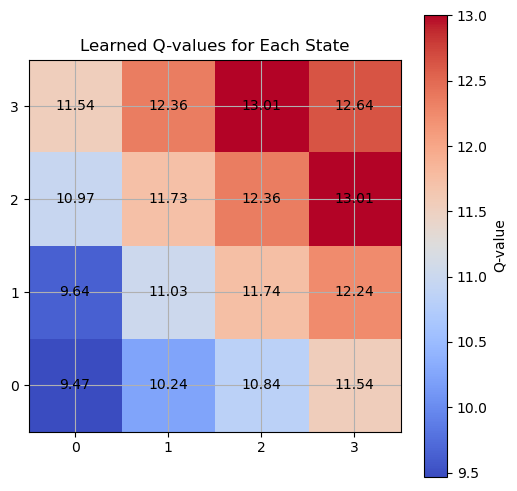

Learned Q-table:
[[ 7.96197525  9.46876168  8.73251549  7.78583204]
 [ 7.88387767 10.23521598  9.11083643  9.66613656]
 [ 9.51438529 10.02444504  9.79541376 10.8366435 ]
 [ 9.3043085   7.91734409  7.78699971 11.54255358]
 [ 7.45231151  7.77720785  8.48815558  9.64280128]
 [ 7.30338459  9.715211    8.89332082 11.02719128]
 [ 9.89431086 10.22641086 10.12443893 11.73610833]
 [10.91528851 10.24525047  9.75260679 12.2434428 ]
 [ 9.04491236 10.97235491  8.67767863 10.1919095 ]
 [ 9.97005141 11.73350856  9.80885786  8.801717  ]
 [10.20964198 12.35657269 10.9649786  11.94942745]
 [11.73842308 12.13107074 10.90975532 13.00691862]
 [ 8.35445172 11.54145566  8.91898773  9.52719554]
 [ 8.75275154 12.35505018  8.46251238 11.58884636]
 [10.77633813 13.00689994 10.60684286 12.25546063]
 [11.04872494 12.63886171  7.3715715   9.42269623]]


In [35]:
q_values_grid = np.max(q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(q_table)

### Conclusion:

* Each row index (0–15) represents a state in the 4×4 grid.
* Each column value shows the Q-value for the actions [Left, Right, Up, Down].
* Higher Q-values indicate better actions that move the agent closer to the goal.

* For instance:
  * In the last few rows (states 12–15), the Q-values are noticeably higher (around 15–17). This means the agent has learned that these         states are near the goal state (15) and should move toward it.
  * The top rows (states 0–3) have lower Q-values (around 8–13), showing that those positions are far from the goal and require more            steps to reach it.
  * The agent’s policy i.e best action from each state would be the action corresponding to the maximum Q-value in that row.